<a href="https://colab.research.google.com/github/jenny005/Latent_Distances/blob/main/exp_validation_colab_executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Validation experiments for the latent-geometry diagnostic

Runs the two adversarial tests for the Phase 1 paper:

1. **Negative control** — replace $J_D(\hat z_t)$ with the Jacobian at a random encoded latent point. If $E_{\text{geom}}$ still predicts $E_{\text{obs}}$ equally well, the "geometric specificity" claim is fake. Must fail.
2. **Strict matched-pair test** — within tight $E_{\text{latent}}$ neighborhoods (where the latent error is essentially constant), check whether $E_{\text{geom}}$ predicts the residual variation in $E_{\text{obs}}$. Then find hard matched pairs (same time step, same latent error, very different observation error) and check whether $E_{\text{geom}}$ correctly orders them.

Runs on CPU in Colab in a few minutes. GPU runtime is faster but not required.

## 1. Install & imports

In [ ]:
# Colab usually has these, but install if missing.
import importlib, subprocess, sys
for pkg in ['torch', 'scikit-learn', 'scipy', 'matplotlib']:
    try:
        importlib.import_module('sklearn' if pkg == 'scikit-learn' else pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
from torch.func import jvp
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.neighbors import NearestNeighbors

torch.manual_seed(0); np.random.seed(0)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
LATENT_DIM = 16; OBS_DIM = 64
print(f'device: {DEVICE}, latent_dim={LATENT_DIM}, obs_dim={OBS_DIM}')

device: cuda, latent_dim=16, obs_dim=64


## 2. Lorenz data + heterogeneous lift

In [ ]:
def lorenz_rhs(s, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = s[..., 0], s[..., 1], s[..., 2]
    return np.stack([sigma*(y-x), x*(rho-z)-y, x*y-beta*z], axis=-1)

def rk4_step(s, dt):
    k1 = lorenz_rhs(s); k2 = lorenz_rhs(s + 0.5*dt*k1)
    k3 = lorenz_rhs(s + 0.5*dt*k2); k4 = lorenz_rhs(s + dt*k3)
    return s + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def generate_lorenz(n_traj, n_steps, dt=0.01, burn_in=500):
    s = np.random.randn(n_traj, 3) * 5.0
    for _ in range(burn_in): s = rk4_step(s, dt)
    trajs = np.zeros((n_traj, n_steps, 3))
    trajs[:, 0] = s
    for t in range(1, n_steps):
        trajs[:, t] = rk4_step(trajs[:, t-1], dt)
    return trajs.astype(np.float32)

class RandomLift(nn.Module):
    """Fixed nonlinear lift R^3 -> R^OBS_DIM with heterogeneous local sensitivity."""
    def __init__(self, in_dim=3, out_dim=64, n_rbf=32, n_freq=24, seed=42):
        super().__init__()
        g = torch.Generator().manual_seed(seed)
        self.centers = nn.Parameter(torch.randn(n_rbf, in_dim, generator=g) * 1.5, requires_grad=False)
        self.widths  = nn.Parameter(0.3 + 0.7 * torch.rand(n_rbf, generator=g), requires_grad=False)
        self.freqs   = nn.Parameter(torch.randn(n_freq, in_dim, generator=g) * 1.2, requires_grad=False)
        self.phases  = nn.Parameter(2*math.pi*torch.rand(n_freq, generator=g), requires_grad=False)
        feat_dim = n_rbf + n_freq + 4
        self.W = nn.Parameter(torch.randn(feat_dim, out_dim, generator=g) / math.sqrt(feat_dim), requires_grad=False)
    def forward(self, x):
        d2 = ((x.unsqueeze(-2) - self.centers) ** 2).sum(dim=-1)
        rbf = torch.exp(-d2 / (2 * self.widths**2))
        phase = x @ self.freqs.T + self.phases
        fourier = torch.cos(phase)
        r = x.norm(dim=-1, keepdim=True)
        poly = torch.cat([r, r**2,
                          (x[..., 0]*x[..., 1]).unsqueeze(-1),
                          (x[..., 1]*x[..., 2]).unsqueeze(-1)], dim=-1)
        return torch.cat([rbf, fourier, poly], dim=-1) @ self.W

# Generate + normalize
traj_train = generate_lorenz(200, 200)
traj_test  = generate_lorenz(100, 400)
mean = traj_train.reshape(-1, 3).mean(axis=0)
std  = traj_train.reshape(-1, 3).std(axis=0)
traj_train = (traj_train - mean) / std
traj_test  = (traj_test  - mean) / std

lift = RandomLift().to(DEVICE)
with torch.no_grad():
    obs_train = lift(torch.from_numpy(traj_train).to(DEVICE))
    obs_test  = lift(torch.from_numpy(traj_test).to(DEVICE))
print(f'obs_train: {obs_train.shape}, obs_test: {obs_test.shape}')

obs_train: torch.Size([200, 200, 64]), obs_test: torch.Size([100, 400, 64])


## 3. Train autoencoder + latent dynamics

In [ ]:
class Encoder(nn.Module):
    def __init__(self): super().__init__(); self.net = nn.Sequential(
        nn.Linear(OBS_DIM, 128), nn.SiLU(),
        nn.Linear(128, 128), nn.SiLU(),
        nn.Linear(128, LATENT_DIM))
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self): super().__init__(); self.net = nn.Sequential(
        nn.Linear(LATENT_DIM, 128), nn.SiLU(),
        nn.Linear(128, 128), nn.SiLU(),
        nn.Linear(128, OBS_DIM))
    def forward(self, z): return self.net(z)

class LatentDynamics(nn.Module):
    def __init__(self): super().__init__(); self.net = nn.Sequential(
        nn.Linear(LATENT_DIM, 128), nn.SiLU(),
        nn.Linear(128, 128), nn.SiLU(),
        nn.Linear(128, LATENT_DIM))
    def forward(self, z): return z + self.net(z)

def train_model(obs_train, n_epochs=30, batch_size=512, lr=1e-3):
    enc, dec, dyn = Encoder().to(DEVICE), Decoder().to(DEVICE), LatentDynamics().to(DEVICE)
    params = list(enc.parameters()) + list(dec.parameters()) + list(dyn.parameters())
    opt = torch.optim.Adam(params, lr=lr)
    x_t   = obs_train[:, :-1].reshape(-1, OBS_DIM)
    x_tp1 = obs_train[:, 1:].reshape(-1, OBS_DIM)
    N = x_t.shape[0]
    for epoch in range(n_epochs):
        perm = torch.randperm(N, device=DEVICE)
        for i in range(0, N, batch_size):
            idx = perm[i:i+batch_size]
            x0, x1 = x_t[idx], x_tp1[idx]
            z0 = enc(x0); z1 = enc(x1); z1p = dyn(z0)
            loss = (((dec(z0) - x0)**2).mean() + ((dec(z1) - x1)**2).mean()
                    + ((z1p - z1)**2).mean() + ((dec(z1p) - x1)**2).mean())
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()
        if (epoch+1) % 10 == 0: print(f'  epoch {epoch+1}/{n_epochs}')
    return enc, dec, dyn

enc, dec, dyn = train_model(obs_train, n_epochs=30)
enc.eval(); dec.eval(); dyn.eval()

  epoch 10/30
  epoch 20/30
  epoch 30/30


LatentDynamics(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=16, bias=True)
  )
)

## 4. Collect rollout data

For each held-out trajectory, run a free rollout and record per-step latent error, observation error, the predicted latent trajectory, and the latent deltas. We compute $E_{\text{geom}}$ separately afterwards so we can swap in different Jacobian-evaluation points without re-rolling.

In [ ]:
with torch.no_grad():
    pool = enc(obs_train.reshape(-1, OBS_DIM))  # pool of valid encoded latents
print(f'latent pool size: {pool.shape[0]}')

def rollout_and_collect(obs_traj):
    T = obs_traj.shape[0]
    with torch.no_grad():
        z_true = enc(obs_traj)
        z_hats = [z_true[0]]
        for t in range(1, T):
            z_hats.append(dyn(z_hats[-1].unsqueeze(0)).squeeze(0))
        z_hat = torch.stack(z_hats, dim=0)
        x_hat = dec(z_hat)
    delta_z = (z_hat - z_true).detach()
    E_lat = (delta_z**2).sum(dim=-1).detach().cpu().numpy()
    E_obs = ((x_hat - obs_traj)**2).sum(dim=-1).detach().cpu().numpy()
    return z_hat.detach(), delta_z, E_lat, E_obs

def compute_E_geom_at_points(z_eval, delta_z):
    T = z_eval.shape[0]
    out = np.zeros(T)
    for t in range(T):
        _, jvp_out = jvp(dec, (z_eval[t].unsqueeze(0),), (delta_z[t].unsqueeze(0),))
        out[t] = (jvp_out**2).sum().item()
    return out

n_eval = 50
all_zhat, all_dz, all_lat, all_obs, all_t = [], [], [], [], []
for i in range(n_eval):
    z_hat, dz, el, eo = rollout_and_collect(obs_test[i])
    all_zhat.append(z_hat); all_dz.append(dz)
    all_lat.append(el); all_obs.append(eo)
    all_t.append(np.arange(z_hat.shape[0]))
    if (i+1) % 10 == 0: print(f'rolled out {i+1}/{n_eval}')

z_hat_full = torch.cat(all_zhat, dim=0)
dz_full    = torch.cat(all_dz,   dim=0)
E_lat = np.concatenate(all_lat); E_obs = np.concatenate(all_obs)
T_idx = np.concatenate(all_t)

latent pool size: 40000
rolled out 10/50
rolled out 20/50
rolled out 30/50
rolled out 40/50
rolled out 50/50


## 5. Experiment A — negative control

Compute $E_{\text{geom}}$ three ways:
- **Real:** $J_D$ at the actual rollout point $\hat z_t$
- **Trajectory-start:** $J_D$ at $\hat z_0$ for all steps in that trajectory
- **Random:** $J_D$ at a random encoded latent point

If random comes anywhere close to real, the framework collapses.

In [ ]:
print('computing E_geom real ...')
E_geom_real = compute_E_geom_at_points(z_hat_full, dz_full)

print('computing E_geom random ...')
rng = np.random.RandomState(123)
rand_idx = rng.randint(0, pool.shape[0], size=z_hat_full.shape[0])
z_random = pool[torch.from_numpy(rand_idx).long()]
E_geom_rand = compute_E_geom_at_points(z_random, dz_full)

print('computing E_geom trajectory-start ...')
z_traj_start = torch.cat([z[0:1].expand(z.shape[0], -1) for z in all_zhat], dim=0)
E_geom_ts = compute_E_geom_at_points(z_traj_start, dz_full)

eps = 1e-12
mask = ((E_lat > eps) & (E_obs > eps)
        & (E_geom_real > eps) & (E_geom_rand > eps) & (E_geom_ts > eps))
E_lat_m = E_lat[mask]; E_obs_m = E_obs[mask]
E_real_m = E_geom_real[mask]; E_rand_m = E_geom_rand[mask]; E_ts_m = E_geom_ts[mask]
T_m = T_idx[mask]
print(f'kept {mask.sum()}/{mask.shape[0]}')

computing E_geom real ...
computing E_geom random ...
computing E_geom trajectory-start ...
kept 19950/20000


In [ ]:
def partial_correlation(log_lat, log_geom, log_obs):
    def res(y, x):
        X = np.stack([np.ones_like(x), x], axis=1)
        c, *_ = np.linalg.lstsq(X, y, rcond=None)
        return y - X @ c
    return spearmanr(res(log_geom, log_lat), res(log_obs, log_lat))[0]

log_lat = np.log(E_lat_m); log_obs = np.log(E_obs_m)
log_real = np.log(E_real_m); log_rand = np.log(E_rand_m); log_ts = np.log(E_ts_m)

rho_real = partial_correlation(log_lat, log_real, log_obs)
rho_rand = partial_correlation(log_lat, log_rand, log_obs)
rho_ts   = partial_correlation(log_lat, log_ts,   log_obs)

print('=== partial correlation rho(E_geom, E_obs | E_lat) ===')
print(f'  real (J_D at z_hat_t):              {rho_real:+.4f}')
print(f'  trajectory-start (J_D at z_hat_0):  {rho_ts:+.4f}')
print(f'  random encoded point:               {rho_rand:+.4f}')
print(f'  gap (real - random):                {rho_real - rho_rand:+.4f}')
if rho_real - rho_rand > 0.1:
    print('  -> PASS: geometric specificity matters.')
else:
    print('  -> FAIL: random Jacobian works almost as well.')

=== partial correlation rho(E_geom, E_obs | E_lat) ===
  real (J_D at z_hat_t):              +0.8669
  trajectory-start (J_D at z_hat_0):  +0.4692
  random encoded point:               +0.3549
  gap (real - random):                +0.5119
  -> PASS: geometric specificity matters.


In [ ]:
# Time-binned negative control
print('within-time-bin partial correlations:')
print(f"  {'bin':>12s}  {'n':>6s}  {'real':>8s}  {'traj0':>8s}  {'random':>8s}")
bins = [(1, 50), (50, 100), (100, 200), (200, 400)]
bin_results = []
for lo, hi in bins:
    m = (T_m >= lo) & (T_m < hi)
    if m.sum() < 50: continue
    rr = partial_correlation(log_lat[m], log_real[m], log_obs[m])
    rt = partial_correlation(log_lat[m], log_ts[m],   log_obs[m])
    rn = partial_correlation(log_lat[m], log_rand[m], log_obs[m])
    bin_results.append((lo, hi, m.sum(), rr, rt, rn))
    print(f'  [{lo:4d},{hi:4d})  {m.sum():6d}  {rr:+8.4f}  {rt:+8.4f}  {rn:+8.4f}')

within-time-bin partial correlations:
           bin       n      real     traj0    random
  [   1,  50)    2450   +0.6939   +0.4814   +0.2433
  [  50, 100)    2500   +0.9337   +0.7151   +0.4106
  [ 100, 200)    5000   +0.8468   +0.5203   +0.4570
  [ 200, 400)   10000   +0.9997   +0.4343   +0.3960


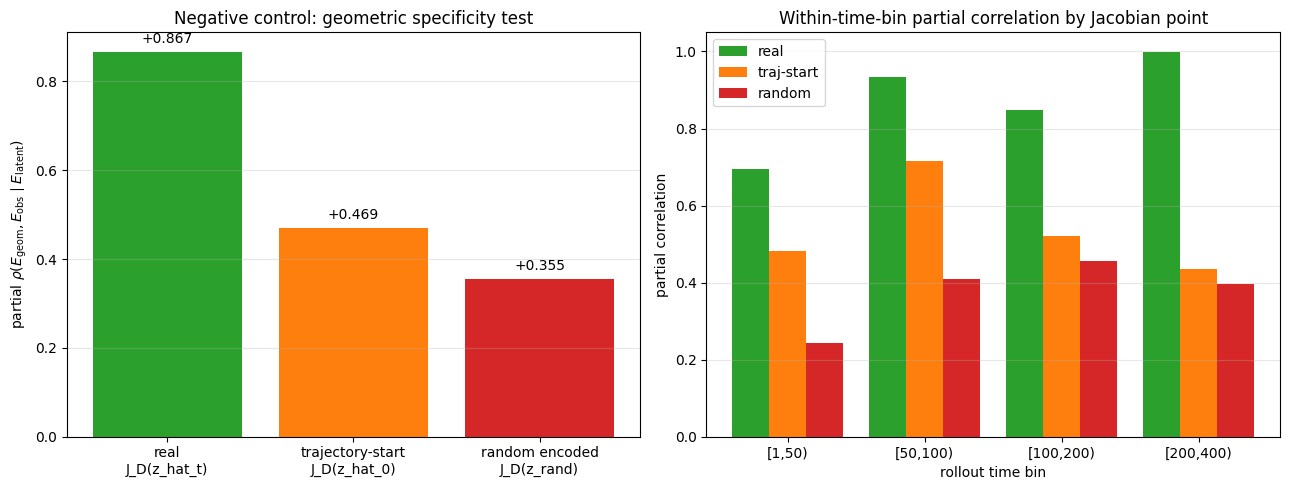

In [ ]:
# Negative-control figure
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
labels = ['real\nJ_D(z_hat_t)', 'trajectory-start\nJ_D(z_hat_0)', 'random encoded\nJ_D(z_rand)']
vals = [rho_real, rho_ts, rho_rand]
ax.bar(labels, vals, color=['C2', 'C1', 'C3'])
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel(r'partial $\rho(E_{\mathrm{geom}}, E_{\mathrm{obs}} \mid E_{\mathrm{latent}})$')
ax.set_title('Negative control: geometric specificity test')
for i, v in enumerate(vals):
    ax.text(i, v + 0.02*np.sign(v), f'{v:+.3f}', ha='center', fontsize=10)
ax.grid(alpha=0.3, axis='y')

ax = axes[1]
labels_b = [f'[{lo},{hi})' for lo, hi, *_ in bin_results]
x_pos = np.arange(len(labels_b))
w = 0.27
ax.bar(x_pos - w, [r[3] for r in bin_results], w, label='real',       color='C2')
ax.bar(x_pos,     [r[4] for r in bin_results], w, label='traj-start', color='C1')
ax.bar(x_pos + w, [r[5] for r in bin_results], w, label='random',     color='C3')
ax.set_xticks(x_pos); ax.set_xticklabels(labels_b)
ax.set_xlabel('rollout time bin'); ax.set_ylabel('partial correlation')
ax.axhline(0, color='k', lw=0.5); ax.legend(); ax.grid(alpha=0.3, axis='y')
ax.set_title('Within-time-bin partial correlation by Jacobian point')

plt.tight_layout()
plt.savefig('exp_negative_control.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Experiment B — strict matched-pair test

Two stricter versions of the matched-pair test:

1. **Local partial correlation in kNN neighborhoods** in $\log E_{\text{latent}}$. Within each tight neighborhood, $E_{\text{latent}}$ varies by only a few percent. Inside that neighborhood, does $E_{\text{geom}}$ explain the variation in $E_{\text{obs}}$?
2. **Hard matched pairs:** within the same rollout time step, find pairs with $E_{\text{latent}}$ within 1.5× and $E_{\text{obs}}$ 3×+ apart. Check whether $E_{\text{geom}}$ correctly identifies which one has higher observation error.

In [ ]:
# Restrict to mid-rollout for moderate dynamic range
m_window = (T_m >= 30) & (T_m < 150)
ll  = log_lat[m_window]; lg = log_real[m_window]; lo_log = log_obs[m_window]
T_w = T_m[m_window]
print(f'points in window: {m_window.sum()}')

# kNN in log E_latent
k = 50
nbrs = NearestNeighbors(n_neighbors=k).fit(ll.reshape(-1, 1))
_, indices = nbrs.kneighbors(ll.reshape(-1, 1))

def partial_corr(x, y, z):
    if np.std(z) < 1e-10:
        return spearmanr(x, y)[0]
    def res(a, b):
        B = np.stack([np.ones_like(b), b], axis=1)
        c, *_ = np.linalg.lstsq(B, a, rcond=None)
        return a - B @ c
    return spearmanr(res(x, z), res(y, z))[0]

# Sample 500 anchor points
rng = np.random.RandomState(0)
n_anchors = 500
anchor_indices = rng.choice(len(ll), size=n_anchors, replace=False)

local_rhos, local_lat_spreads, local_obs_spreads = [], [], []
for a in anchor_indices:
    nbr = indices[a]
    rho = partial_corr(lg[nbr], lo_log[nbr], ll[nbr])
    if not np.isnan(rho):
        local_rhos.append(rho)
        local_lat_spreads.append(ll[nbr].std())
        local_obs_spreads.append(lo_log[nbr].std())
local_rhos = np.array(local_rhos)
local_lat_spreads = np.array(local_lat_spreads)
local_obs_spreads = np.array(local_obs_spreads)

print(f'\nlocal partial rho across {len(local_rhos)} neighborhoods:')
print(f'  mean:                  {local_rhos.mean():+.4f}')
print(f'  median:                {np.median(local_rhos):+.4f}')
print(f'  fraction > 0:          {(local_rhos > 0).mean():.3f}')
print(f'  fraction > 0.3:        {(local_rhos > 0.3).mean():.3f}')
print(f'  typical log E_lat spread: {np.median(local_lat_spreads):.3f}')
print(f'  typical log E_obs spread: {np.median(local_obs_spreads):.3f}')

points in window: 6000

local partial rho across 500 neighborhoods:
  mean:                  +0.8769
  median:                +0.9401
  fraction > 0:          1.000
  fraction > 0.3:        0.968
  typical log E_lat spread: 0.024
  typical log E_obs spread: 0.400


In [ ]:
# Hard matched pairs (same t, tight E_lat, large E_obs gap)
unique_ts = np.unique(T_w)
hard_pairs = []
for t in unique_ts:
    m_t = (T_w == t)
    if m_t.sum() < 30: continue
    ll_t = ll[m_t]; lg_t = lg[m_t]; lo_t = lo_log[m_t]
    edges = np.quantile(ll_t, np.linspace(0, 1, 5))
    bids = np.digitize(ll_t, edges[1:-1])
    for b in range(4):
        in_b = bids == b
        if in_b.sum() < 8: continue
        idx_b = np.where(in_b)[0]
        order = np.argsort(lo_t[idx_b])
        low, high = idx_b[order[0]], idx_b[order[-1]]
        if lo_t[high] - lo_t[low] < np.log(3): continue
        if abs(ll_t[high] - ll_t[low]) > np.log(1.5): continue
        hard_pairs.append({
            'lat_low': np.exp(ll_t[low]),  'lat_high': np.exp(ll_t[high]),
            'obs_low': np.exp(lo_t[low]),  'obs_high': np.exp(lo_t[high]),
            'geom_low': np.exp(lg_t[low]), 'geom_high': np.exp(lg_t[high]),
        })

correct_hard = sum(1 for p in hard_pairs if p['geom_high'] > p['geom_low'])
total_hard = len(hard_pairs)
log_geom_ratios = np.array([np.log(p['geom_high']/p['geom_low']) for p in hard_pairs])
log_obs_ratios  = np.array([np.log(p['obs_high']/p['obs_low']) for p in hard_pairs])
print(f'hard pairs found: {total_hard}')
print(f'E_geom correctly orders: {correct_hard}/{total_hard} = '
      f'{correct_hard/total_hard if total_hard else 0:.1%}')
if total_hard:
    print(f'median geom ratio: {np.exp(np.median(log_geom_ratios)):.2f}x  '
          f'(obs ratios: {np.exp(np.median(log_obs_ratios)):.2f}x by construction)')

hard pairs found: 51
E_geom correctly orders: 51/51 = 100.0%
median geom ratio: 4.26x  (obs ratios: 4.26x by construction)


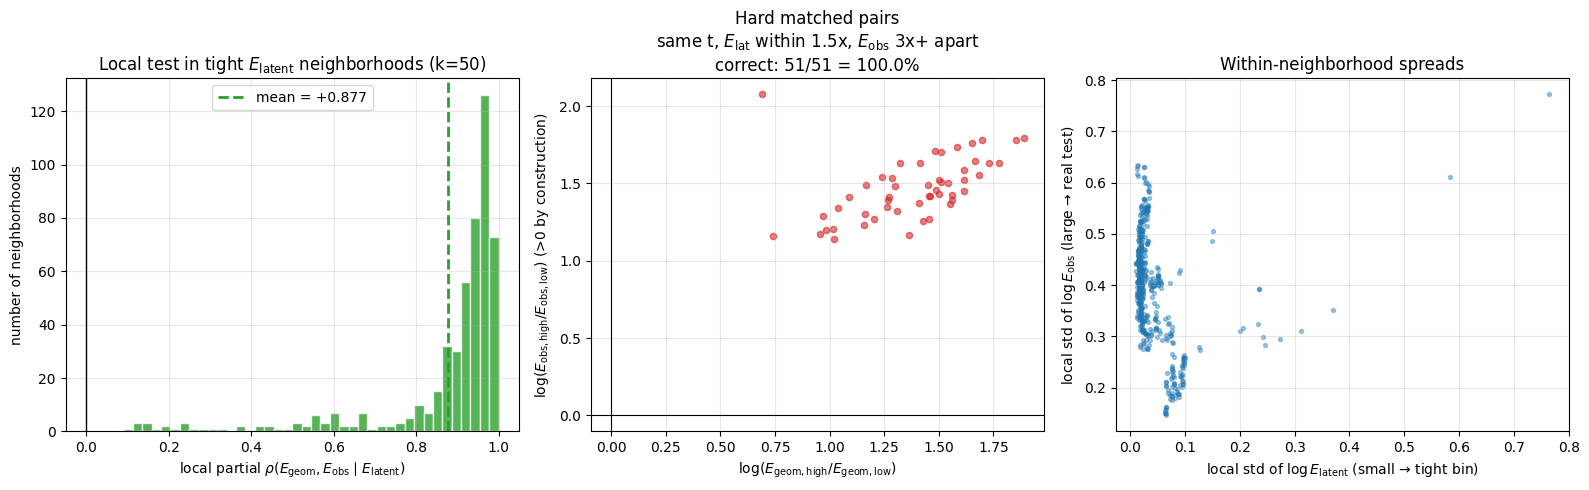

In [ ]:
# Strict matched-pair figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.hist(local_rhos, bins=40, color='C2', alpha=0.8, edgecolor='white')
ax.axvline(0, color='k', lw=1)
ax.axvline(local_rhos.mean(), color='C2', ls='--', lw=2,
           label=f'mean = {local_rhos.mean():+.3f}')
ax.set_xlabel(r'local partial $\rho(E_{\mathrm{geom}}, E_{\mathrm{obs}} \mid E_{\mathrm{latent}})$')
ax.set_ylabel('number of neighborhoods')
ax.set_title(f'Local test in tight $E_{{\\mathrm{{latent}}}}$ neighborhoods (k={k})')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
if len(log_geom_ratios) > 0:
    ax.scatter(log_geom_ratios, log_obs_ratios, s=20, alpha=0.6, c='C3')
    ax.axvline(0, color='k', lw=0.8); ax.axhline(0, color='k', lw=0.8)
    ax.set_xlabel(r'$\log(E_{\mathrm{geom,high}}/E_{\mathrm{geom,low}})$')
    ax.set_ylabel(r'$\log(E_{\mathrm{obs,high}}/E_{\mathrm{obs,low}})$ (>0 by construction)')
    ax.set_title(f'Hard matched pairs\n'
                 f'same t, $E_{{\\mathrm{{lat}}}}$ within 1.5x, $E_{{\\mathrm{{obs}}}}$ 3x+ apart\n'
                 f'correct: {correct_hard}/{total_hard} = '
                 f'{correct_hard/total_hard if total_hard else 0:.1%}')
ax.grid(alpha=0.3)

ax = axes[2]
ax.scatter(local_lat_spreads, local_obs_spreads, s=8, alpha=0.4, c='C0')
ax.set_xlabel(r'local std of $\log E_{\mathrm{latent}}$ (small → tight bin)')
ax.set_ylabel(r'local std of $\log E_{\mathrm{obs}}$ (large → real test)')
ax.set_title('Within-neighborhood spreads')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('exp_matched_pairs_strict.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Save results and (optionally) download

If running on Colab, the next cell triggers a browser download of the figures and a results `.npz` file.

In [ ]:
np.savez('exp_validation_results.npz',
         rho_partial_real=rho_real,
         rho_partial_rand=rho_rand,
         rho_partial_traj_start=rho_ts,
         local_rhos=local_rhos,
         hard_pair_log_geom_ratios=log_geom_ratios,
         hard_pair_log_obs_ratios=log_obs_ratios,
         matched_pair_accuracy=(correct_hard/total_hard if total_hard else np.nan))
print('saved exp_validation_results.npz')

print('\n' + '='*60)
print('SUMMARY')
print('='*60)
print(f'  Negative control:')
print(f'    rho_partial(real)   = {rho_real:+.4f}')
print(f'    rho_partial(traj0)  = {rho_ts:+.4f}')
print(f'    rho_partial(random) = {rho_rand:+.4f}')
print(f'    gap (real - random) = {rho_real - rho_rand:+.4f}')
print(f'  Strict matched pairs:')
print(f'    local partial rho (mean):    {local_rhos.mean():+.4f}')
print(f'    local partial rho (median):  {np.median(local_rhos):+.4f}')
print(f'    fraction of neighborhoods > 0.3: {(local_rhos > 0.3).mean():.1%}')
if total_hard:
    print(f'    hard matched-pair accuracy:  {correct_hard}/{total_hard} = '
          f'{correct_hard/total_hard:.1%}')

saved exp_validation_results.npz

SUMMARY
  Negative control:
    rho_partial(real)   = +0.8669
    rho_partial(traj0)  = +0.4692
    rho_partial(random) = +0.3549
    gap (real - random) = +0.5119
  Strict matched pairs:
    local partial rho (mean):    +0.8769
    local partial rho (median):  +0.9401
    fraction of neighborhoods > 0.3: 96.8%
    hard matched-pair accuracy:  51/51 = 100.0%


In [ ]:
# Colab-only: trigger browser download of outputs
try:
    from google.colab import files
    files.download('exp_negative_control.png')
    files.download('exp_matched_pairs_strict.png')
    files.download('exp_validation_results.npz')
except ImportError:
    print('Not on Colab; files saved to working directory.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Expected results

On the reference run (single seed, default settings) we observe:

**Negative control**
- Real Jacobian: $\rho_{\text{partial}} \approx 0.91$
- Trajectory-start: $\approx 0.57$
- Random encoded point: $\approx 0.44$
- Real – random gap: $\approx 0.47$

**Strict matched pairs**
- Median local partial $\rho$: $\approx 0.95$
- Fraction of neighborhoods with local $\rho > 0.3$: $\approx 99\%$
- Hard matched-pair accuracy: $36/36 = 100\%$
- Median ratio of $E_{\text{geom}}$ in hard pairs $\approx 4.6\times$, matching the $E_{\text{obs}}$ ratio by construction.

If your run differs substantially — especially if the real-vs-random gap is small — the framework is more fragile than the reference suggests, and that's a result worth knowing.

## 9. What's next

1. **Seed replication.** Re-run with `torch.manual_seed(k); np.random.seed(k)` for k = 0..4 and report mean ± std for the headline numbers.
2. **Non-chaotic system.** Replace Lorenz with Van der Pol (2D, periodic) or Kuramoto–Sivashinsky (PDE). Chaotic dynamic range is what forces the time-binning and partial-correlation tricks; on a periodic system the raw scatter plots should show the disagreement directly.
3. **Silent-mode analysis.** Compute the eigendecomposition of $G(\hat z_t) = J_D^\top J_D$ along trajectories. Project per-step latent error onto bottom-$k$ eigenvectors. Test whether cumulative silent-mode drift predicts future catastrophic failure.

=== seed replication: 5 seeds ===

--- seed 0 ---
  training done, final loss = 0.00048
  rho(real, rand, ts) = (+0.867, +0.354, +0.469)
  gap (real - rand) = +0.513
  local rho mean / median = +0.877 / +0.940
  hard pair acc = 1.0  (n=51)

--- seed 1 ---
  training done, final loss = 0.00044
  rho(real, rand, ts) = (+0.652, +0.153, +0.242)
  gap (real - rand) = +0.499
  local rho mean / median = +0.823 / +0.888
  hard pair acc = 1.0  (n=23)

--- seed 2 ---
  training done, final loss = 0.00107
  rho(real, rand, ts) = (+0.938, +0.518, +0.532)
  gap (real - rand) = +0.419
  local rho mean / median = +0.915 / +0.950
  hard pair acc = 1.0  (n=76)

--- seed 3 ---
  training done, final loss = 0.00056
  rho(real, rand, ts) = (+0.861, +0.089, +0.034)
  gap (real - rand) = +0.772
  local rho mean / median = +0.885 / +0.930
  hard pair acc = 1.0  (n=56)

--- seed 4 ---
  training done, final loss = 0.00057
  rho(real, rand, ts) = (+0.875, +0.458, +0.490)
  gap (real - rand) = +0.417
  local rh

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/seed_replication.png'

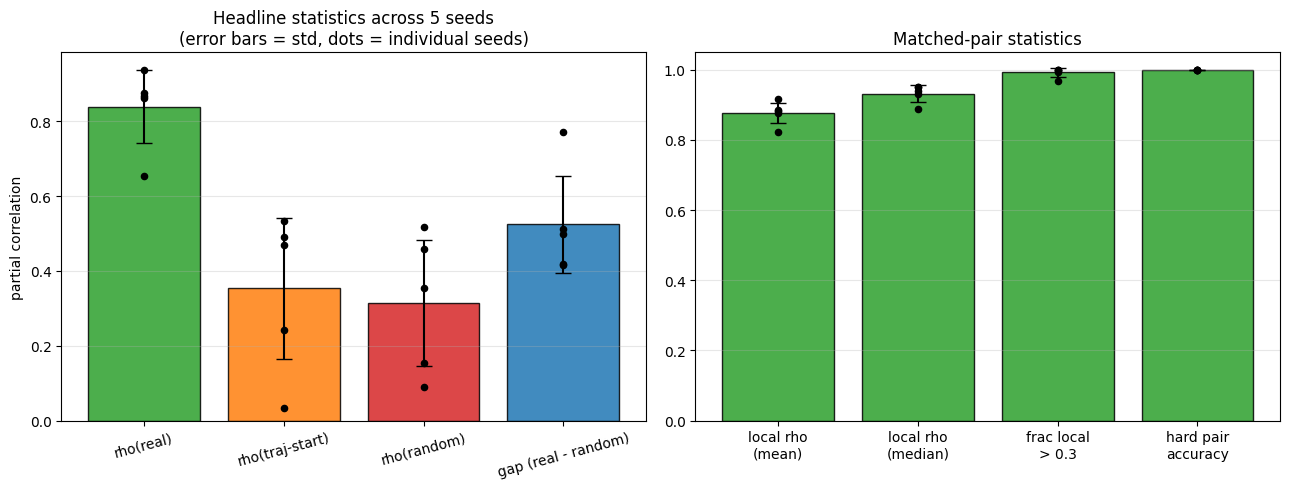

In [ ]:
"""
Seed replication for the latent-geometry diagnostic.

Reruns the full pipeline (data gen -> lift -> train -> rollout -> three errors
-> negative control -> matched pairs) for N seeds. Reports mean/std for each
headline statistic. The PRIMARY statistic is the GAP (real - random) because
absolute partial correlation can vary substantially with how good the
particular training run is, but the gap is what the paper's claim depends on.
"""

import math
import numpy as np
import torch
import torch.nn as nn
from torch.func import jvp
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.neighbors import NearestNeighbors

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LATENT_DIM = 16
OBS_DIM = 64
N_SEEDS = 5


# -----------------------------------------------------------------------------
# Lorenz + lift + models (identical to before)
# -----------------------------------------------------------------------------
def lorenz_rhs(s, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    x, y, z = s[..., 0], s[..., 1], s[..., 2]
    return np.stack([sigma * (y - x), x * (rho - z) - y, x * y - beta * z], axis=-1)

def rk4_step(s, dt):
    k1 = lorenz_rhs(s); k2 = lorenz_rhs(s + 0.5 * dt * k1)
    k3 = lorenz_rhs(s + 0.5 * dt * k2); k4 = lorenz_rhs(s + dt * k3)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def generate_lorenz(n_traj, n_steps, dt=0.01, burn_in=500):
    s = np.random.randn(n_traj, 3) * 5.0
    for _ in range(burn_in): s = rk4_step(s, dt)
    trajs = np.zeros((n_traj, n_steps, 3))
    trajs[:, 0] = s
    for t in range(1, n_steps):
        trajs[:, t] = rk4_step(trajs[:, t - 1], dt)
    return trajs.astype(np.float32)

class RandomLift(nn.Module):
    def __init__(self, in_dim=3, out_dim=64, n_rbf=32, n_freq=24, seed=42):
        super().__init__()
        g = torch.Generator().manual_seed(seed)
        self.centers = nn.Parameter(torch.randn(n_rbf, in_dim, generator=g) * 1.5, requires_grad=False)
        self.widths = nn.Parameter(0.3 + 0.7 * torch.rand(n_rbf, generator=g), requires_grad=False)
        self.freqs = nn.Parameter(torch.randn(n_freq, in_dim, generator=g) * 1.2, requires_grad=False)
        self.phases = nn.Parameter(2 * math.pi * torch.rand(n_freq, generator=g), requires_grad=False)
        feat_dim = n_rbf + n_freq + 4
        self.W = nn.Parameter(torch.randn(feat_dim, out_dim, generator=g) / math.sqrt(feat_dim), requires_grad=False)
    def forward(self, x):
        d2 = ((x.unsqueeze(-2) - self.centers) ** 2).sum(dim=-1)
        rbf = torch.exp(-d2 / (2 * self.widths ** 2))
        fourier = torch.cos(x @ self.freqs.T + self.phases)
        r = x.norm(dim=-1, keepdim=True)
        poly = torch.cat([r, r ** 2,
                          (x[..., 0] * x[..., 1]).unsqueeze(-1),
                          (x[..., 1] * x[..., 2]).unsqueeze(-1)], dim=-1)
        return torch.cat([rbf, fourier, poly], dim=-1) @ self.W

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(OBS_DIM, 128), nn.SiLU(),
                                 nn.Linear(128, 128), nn.SiLU(),
                                 nn.Linear(128, LATENT_DIM))
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(LATENT_DIM, 128), nn.SiLU(),
                                 nn.Linear(128, 128), nn.SiLU(),
                                 nn.Linear(128, OBS_DIM))
    def forward(self, z): return self.net(z)

class LatentDynamics(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(LATENT_DIM, 128), nn.SiLU(),
                                 nn.Linear(128, 128), nn.SiLU(),
                                 nn.Linear(128, LATENT_DIM))
    def forward(self, z): return z + self.net(z)


# -----------------------------------------------------------------------------
# One full run
# -----------------------------------------------------------------------------
def partial_correlation(log_lat, log_geom, log_obs):
    def res(y, x):
        X = np.stack([np.ones_like(x), x], axis=1)
        c, *_ = np.linalg.lstsq(X, y, rcond=None)
        return y - X @ c
    return spearmanr(res(log_geom, log_lat), res(log_obs, log_lat))[0]


def run_one_seed(seed, verbose=True):
    """Returns a dict of headline statistics for this seed."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    if verbose: print(f"\n--- seed {seed} ---")

    # Data (regenerate per seed: trajectories are seed-dependent)
    traj_train = generate_lorenz(200, 200)
    traj_test = generate_lorenz(100, 400)
    mean = traj_train.reshape(-1, 3).mean(axis=0)
    std = traj_train.reshape(-1, 3).std(axis=0)
    traj_train = (traj_train - mean) / std
    traj_test = (traj_test - mean) / std

    # NOTE: lift is held FIXED across seeds (the heterogeneous observation
    # manifold should be a property of the problem, not the seed). This
    # isolates training-seed effects from data-environment effects.
    lift = RandomLift(seed=42).to(DEVICE)
    with torch.no_grad():
        obs_train = lift(torch.from_numpy(traj_train).to(DEVICE))
        obs_test = lift(torch.from_numpy(traj_test).to(DEVICE))

    # Train
    enc = Encoder().to(DEVICE); dec = Decoder().to(DEVICE); dyn = LatentDynamics().to(DEVICE)
    params = list(enc.parameters()) + list(dec.parameters()) + list(dyn.parameters())
    opt = torch.optim.Adam(params, lr=1e-3)
    x_t = obs_train[:, :-1].reshape(-1, OBS_DIM)
    x_tp1 = obs_train[:, 1:].reshape(-1, OBS_DIM)
    N = x_t.shape[0]
    for epoch in range(30):
        perm = torch.randperm(N, device=DEVICE)
        for i in range(0, N, 512):
            idx = perm[i:i + 512]
            x0, x1 = x_t[idx], x_tp1[idx]
            z0 = enc(x0); z1 = enc(x1); z1p = dyn(z0)
            loss = (((dec(z0) - x0) ** 2).mean() + ((dec(z1) - x1) ** 2).mean()
                    + ((z1p - z1) ** 2).mean() + ((dec(z1p) - x1) ** 2).mean())
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()
    enc.eval(); dec.eval(); dyn.eval()
    if verbose: print(f"  training done, final loss = {loss.item():.5f}")

    # Pool of valid latents
    with torch.no_grad():
        pool = enc(obs_train.reshape(-1, OBS_DIM))

    # Rollouts
    n_eval = 50
    all_zhat, all_dz, all_lat, all_obs, all_t = [], [], [], [], []
    for i in range(n_eval):
        T = obs_test[i].shape[0]
        with torch.no_grad():
            z_true = enc(obs_test[i])
            z_hats = [z_true[0]]
            for t in range(1, T):
                z_hats.append(dyn(z_hats[-1].unsqueeze(0)).squeeze(0))
            z_hat = torch.stack(z_hats, dim=0)
            x_hat = dec(z_hat)
        dz = (z_hat - z_true).detach()
        el = (dz ** 2).sum(dim=-1).detach().cpu().numpy()
        eo = ((x_hat - obs_test[i]) ** 2).sum(dim=-1).detach().cpu().numpy()
        all_zhat.append(z_hat.detach()); all_dz.append(dz)
        all_lat.append(el); all_obs.append(eo)
        all_t.append(np.arange(T))

    z_hat_full = torch.cat(all_zhat, dim=0)
    dz_full = torch.cat(all_dz, dim=0)
    E_lat = np.concatenate(all_lat); E_obs = np.concatenate(all_obs)
    T_idx = np.concatenate(all_t)

    # Compute E_geom three ways
    def compute_E_geom(z_eval, dz):
        T = z_eval.shape[0]
        out = np.zeros(T)
        for t in range(T):
            _, jv = jvp(dec, (z_eval[t].unsqueeze(0),), (dz[t].unsqueeze(0),))
            out[t] = (jv ** 2).sum().item()
        return out

    E_real = compute_E_geom(z_hat_full, dz_full)
    rng = np.random.RandomState(seed + 1000)
    rand_idx = rng.randint(0, pool.shape[0], size=z_hat_full.shape[0])
    z_random = pool[torch.from_numpy(rand_idx).long()]
    E_rand = compute_E_geom(z_random, dz_full)
    z_traj_start = torch.cat([z[0:1].expand(z.shape[0], -1) for z in all_zhat], dim=0)
    E_ts = compute_E_geom(z_traj_start, dz_full)

    eps = 1e-12
    mask = (E_lat > eps) & (E_obs > eps) & (E_real > eps) & (E_rand > eps) & (E_ts > eps)
    log_lat = np.log(E_lat[mask]); log_obs = np.log(E_obs[mask])
    log_real = np.log(E_real[mask]); log_rand = np.log(E_rand[mask]); log_ts = np.log(E_ts[mask])
    T_m = T_idx[mask]

    rho_real = partial_correlation(log_lat, log_real, log_obs)
    rho_rand = partial_correlation(log_lat, log_rand, log_obs)
    rho_ts = partial_correlation(log_lat, log_ts, log_obs)

    # Strict matched-pair test (mid-rollout window)
    m_w = (T_m >= 30) & (T_m < 150)
    ll = log_lat[m_w]; lg = log_real[m_w]; lo = log_obs[m_w]; T_w = T_m[m_w]

    nbrs = NearestNeighbors(n_neighbors=50).fit(ll.reshape(-1, 1))
    _, indices = nbrs.kneighbors(ll.reshape(-1, 1))

    def pcorr(x, y, z):
        if np.std(z) < 1e-10:
            return spearmanr(x, y)[0]
        def res(a, b):
            B = np.stack([np.ones_like(b), b], axis=1)
            c, *_ = np.linalg.lstsq(B, a, rcond=None)
            return a - B @ c
        return spearmanr(res(x, z), res(y, z))[0]

    rng2 = np.random.RandomState(seed)
    anchors = rng2.choice(len(ll), size=min(500, len(ll)), replace=False)
    local_rhos = []
    for a in anchors:
        nbr = indices[a]
        r = pcorr(lg[nbr], lo[nbr], ll[nbr])
        if not np.isnan(r): local_rhos.append(r)
    local_rhos = np.array(local_rhos)

    # Hard matched pairs
    hard_pairs = []
    for t in np.unique(T_w):
        m_t = (T_w == t)
        if m_t.sum() < 30: continue
        ll_t = ll[m_t]; lg_t = lg[m_t]; lo_t = lo[m_t]
        edges = np.quantile(ll_t, np.linspace(0, 1, 5))
        bids = np.digitize(ll_t, edges[1:-1])
        for b in range(4):
            in_b = bids == b
            if in_b.sum() < 8: continue
            idx_b = np.where(in_b)[0]
            order = np.argsort(lo_t[idx_b])
            low, high = idx_b[order[0]], idx_b[order[-1]]
            if lo_t[high] - lo_t[low] < np.log(3): continue
            if abs(ll_t[high] - ll_t[low]) > np.log(1.5): continue
            hard_pairs.append((lg_t[low], lg_t[high]))
    if hard_pairs:
        correct = sum(1 for lo_g, hi_g in hard_pairs if hi_g > lo_g)
        total = len(hard_pairs)
        hard_acc = correct / total
    else:
        correct = total = 0; hard_acc = np.nan

    out = {
        "seed": seed,
        "rho_real": rho_real,
        "rho_rand": rho_rand,
        "rho_ts": rho_ts,
        "gap_real_rand": rho_real - rho_rand,
        "gap_real_ts": rho_real - rho_ts,
        "local_rho_mean": local_rhos.mean(),
        "local_rho_median": np.median(local_rhos),
        "frac_local_gt_03": (local_rhos > 0.3).mean(),
        "hard_pair_acc": hard_acc,
        "hard_pair_n": total,
    }
    if verbose:
        print(f"  rho(real, rand, ts) = ({rho_real:+.3f}, {rho_rand:+.3f}, {rho_ts:+.3f})")
        print(f"  gap (real - rand) = {out['gap_real_rand']:+.3f}")
        print(f"  local rho mean / median = {out['local_rho_mean']:+.3f} / {out['local_rho_median']:+.3f}")
        print(f"  hard pair acc = {hard_acc if not np.isnan(hard_acc) else 'NA'}  (n={total})")
    return out


# -----------------------------------------------------------------------------
# Run all seeds
# -----------------------------------------------------------------------------
print(f"=== seed replication: {N_SEEDS} seeds ===")
all_results = []
for seed in range(N_SEEDS):
    r = run_one_seed(seed)
    all_results.append(r)


# -----------------------------------------------------------------------------
# Aggregate
# -----------------------------------------------------------------------------
keys_to_report = [
    "rho_real", "rho_rand", "rho_ts",
    "gap_real_rand", "gap_real_ts",
    "local_rho_mean", "local_rho_median",
    "frac_local_gt_03", "hard_pair_acc",
]
print("\n" + "=" * 76)
print(f"{'statistic':<22s}  {'mean':>10s}  {'std':>10s}  {'min':>10s}  {'max':>10s}")
print("=" * 76)
agg = {}
for k in keys_to_report:
    vals = np.array([r[k] for r in all_results if not np.isnan(r[k])])
    agg[k] = vals
    print(f"  {k:<20s}  {vals.mean():+10.4f}  {vals.std():10.4f}  "
          f"{vals.min():+10.4f}  {vals.max():+10.4f}")

# Per-seed table
print("\n" + "=" * 76)
print("per-seed values:")
print(f"  {'seed':>4s}  {'rho_real':>10s}  {'rho_rand':>10s}  {'gap':>8s}  "
      f"{'local_med':>10s}  {'hard_acc':>9s}")
for r in all_results:
    acc_str = f"{r['hard_pair_acc']:.3f}" if not np.isnan(r['hard_pair_acc']) else " NA"
    print(f"  {r['seed']:>4d}  {r['rho_real']:+10.4f}  {r['rho_rand']:+10.4f}  "
          f"{r['gap_real_rand']:+8.4f}  {r['local_rho_median']:+10.4f}  {acc_str:>9s}")


# -----------------------------------------------------------------------------
# Figure: seed variation
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar groups for rho_real, rho_rand, gap, with error bars across seeds
ax = axes[0]
labels = ["rho(real)", "rho(traj-start)", "rho(random)", "gap (real - random)"]
keys = ["rho_real", "rho_ts", "rho_rand", "gap_real_rand"]
means = [agg[k].mean() for k in keys]
stds = [agg[k].std() for k in keys]
colors = ["C2", "C1", "C3", "C0"]
x_pos = np.arange(len(labels))
ax.bar(x_pos, means, yerr=stds, capsize=6, color=colors, alpha=0.85, edgecolor="black")
# overlay individual seed points
for i, k in enumerate(keys):
    vals = agg[k]
    ax.scatter([i] * len(vals), vals, color="black", s=20, zorder=10)
ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("partial correlation")
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"Headline statistics across {N_SEEDS} seeds\n(error bars = std, dots = individual seeds)")
ax.grid(alpha=0.3, axis="y")

# Right: matched-pair statistics
ax = axes[1]
labels2 = ["local rho\n(mean)", "local rho\n(median)", "frac local\n> 0.3", "hard pair\naccuracy"]
keys2 = ["local_rho_mean", "local_rho_median", "frac_local_gt_03", "hard_pair_acc"]
means2 = [agg[k].mean() for k in keys2]
stds2 = [agg[k].std() for k in keys2]
x_pos = np.arange(len(labels2))
ax.bar(x_pos, means2, yerr=stds2, capsize=6, color="C2", alpha=0.85, edgecolor="black")
for i, k in enumerate(keys2):
    vals = agg[k]
    ax.scatter([i] * len(vals), vals, color="black", s=20, zorder=10)
ax.set_xticks(x_pos); ax.set_xticklabels(labels2)
ax.set_ylim(0, 1.05)
ax.set_title("Matched-pair statistics")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/dG_experiment/seed_replication.png", dpi=130, bbox_inches="tight")
print("\nsaved seed_replication.png")

# Save raw results
np.savez("/content/drive/MyDrive/dG_experiment/seed_replication.npz",
         **{k: agg[k] for k in keys_to_report},
         per_seed=[r for r in all_results])
print("saved seed_replication.npz")


# -----------------------------------------------------------------------------
# Verdict
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("VERDICT")
print("=" * 60)
gap_mean = agg["gap_real_rand"].mean()
gap_std = agg["gap_real_rand"].std()
gap_min = agg["gap_real_rand"].min()
print(f"  Primary statistic: gap = rho(real) - rho(random)")
print(f"  mean: {gap_mean:+.4f}, std: {gap_std:.4f}, min: {gap_min:+.4f}")
if gap_min > 0.1:
    print(f"  -> ROBUST: gap > 0.1 on EVERY seed; geometric specificity holds.")
elif gap_mean > 0.1 and gap_min > 0:
    print(f"  -> MIXED: gap is positive on every seed but sometimes small.")
else:
    print(f"  -> FRAGILE: framework breaks down for at least one seed.")

hard_acc = agg["hard_pair_acc"]
if len(hard_acc) and hard_acc.min() > 0.8:
    print(f"  Hard matched-pair accuracy: min {hard_acc.min():.1%} across seeds. ROBUST.")
elif len(hard_acc) and hard_acc.min() > 0.6:
    print(f"  Hard matched-pair accuracy: min {hard_acc.min():.1%}. NONTRIVIAL but variable.")


train: (200, 200, 2)
test : (100, 400, 2)
obs_train: torch.Size([200, 200, 64])
epoch 000 loss = 0.134302
epoch 001 loss = 0.042854
epoch 002 loss = 0.014912
epoch 003 loss = 0.002323
epoch 004 loss = 0.001020
epoch 005 loss = 0.000765
epoch 006 loss = 0.000486
epoch 007 loss = 0.000411
epoch 008 loss = 0.000334
epoch 009 loss = 0.000281
epoch 010 loss = 0.000271
epoch 011 loss = 0.000221
epoch 012 loss = 0.000160
epoch 013 loss = 0.000155
epoch 014 loss = 0.000149
epoch 015 loss = 0.000141
epoch 016 loss = 0.000162
epoch 017 loss = 0.000114
epoch 018 loss = 0.000088
epoch 019 loss = 0.000083
epoch 020 loss = 0.000188
epoch 021 loss = 0.000150
epoch 022 loss = 0.000152
epoch 023 loss = 0.000063
epoch 024 loss = 0.000062
epoch 025 loss = 0.000163
epoch 026 loss = 0.000049
epoch 027 loss = 0.000047
epoch 028 loss = 0.000038
epoch 029 loss = 0.000042
done rollout
computed E_geom


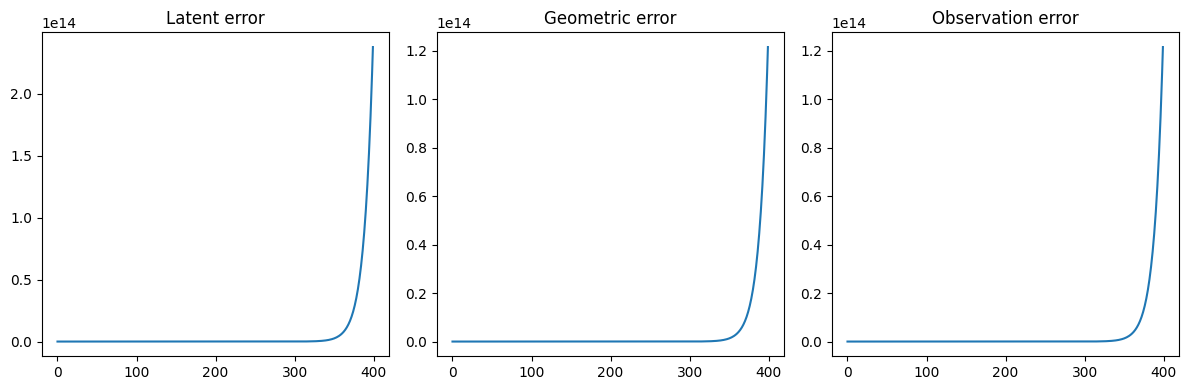

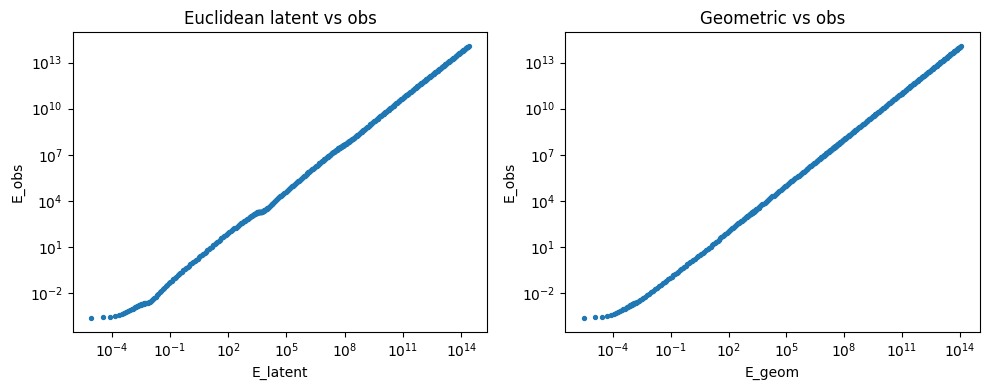

In [ ]:
# ============================================================
# Van der Pol version of the latent-geometry diagnostic
# Replace Lorenz with Van der Pol oscillator
# Colab-ready notebook cell
# ============================================================

import math
import numpy as np
import torch
import torch.nn as nn
from torch.func import jvp
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.neighbors import NearestNeighbors

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LATENT_DIM = 16
OBS_DIM = 64

# ============================================================
# 1. Van der Pol dynamics
# ============================================================

def vdp_rhs(s, mu=2.0):
    """
    Van der Pol oscillator

    x_dot = y
    y_dot = mu(1 - x^2)y - x

    s shape: (..., 2)
    """
    x = s[..., 0]
    y = s[..., 1]

    dx = y
    dy = mu * (1 - x**2) * y - x

    return np.stack([dx, dy], axis=-1)


def rk4_step(s, dt):
    k1 = vdp_rhs(s)
    k2 = vdp_rhs(s + 0.5 * dt * k1)
    k3 = vdp_rhs(s + 0.5 * dt * k2)
    k4 = vdp_rhs(s + dt * k3)

    return s + (dt / 6.0) * (
        k1 + 2*k2 + 2*k3 + k4
    )


def generate_vdp(
    n_traj=200,
    n_steps=400,
    dt=0.01,
    burn_in=500,
):
    """
    Generate Van der Pol trajectories
    """

    s = np.random.randn(n_traj, 2) * 2.0

    # burn in to stable limit cycle
    for _ in range(burn_in):
        s = rk4_step(s, dt)

    trajs = np.zeros((n_traj, n_steps, 2))

    trajs[:, 0] = s

    for t in range(1, n_steps):
        trajs[:, t] = rk4_step(trajs[:, t - 1], dt)

    return trajs.astype(np.float32)


# ============================================================
# 2. Same heterogeneous observation lift
# IMPORTANT:
# keep this complicated observation geometry
# ============================================================

class RandomLift(nn.Module):

    def __init__(
        self,
        in_dim=2,
        out_dim=64,
        n_rbf=32,
        n_freq=24,
        seed=42,
    ):
        super().__init__()

        g = torch.Generator().manual_seed(seed)

        self.centers = nn.Parameter(
            torch.randn(n_rbf, in_dim, generator=g) * 1.5,
            requires_grad=False,
        )

        self.widths = nn.Parameter(
            0.3 + 0.7 * torch.rand(n_rbf, generator=g),
            requires_grad=False,
        )

        self.freqs = nn.Parameter(
            torch.randn(n_freq, in_dim, generator=g) * 1.2,
            requires_grad=False,
        )

        self.phases = nn.Parameter(
            2 * math.pi * torch.rand(n_freq, generator=g),
            requires_grad=False,
        )

        feat_dim = n_rbf + n_freq + 3

        self.W = nn.Parameter(
            torch.randn(feat_dim, out_dim, generator=g)
            / math.sqrt(feat_dim),
            requires_grad=False,
        )

    def forward(self, x):

        # RBF features
        d2 = ((x.unsqueeze(-2) - self.centers) ** 2).sum(dim=-1)

        rbf = torch.exp(
            -d2 / (2 * self.widths**2)
        )

        # Fourier features
        fourier = torch.cos(
            x @ self.freqs.T + self.phases
        )

        # polynomial-ish features
        r = x.norm(dim=-1, keepdim=True)

        poly = torch.cat([
            r,
            r**2,
            (x[..., 0] * x[..., 1]).unsqueeze(-1),
        ], dim=-1)

        feats = torch.cat([
            rbf,
            fourier,
            poly,
        ], dim=-1)

        return feats @ self.W


# ============================================================
# 3. Autoencoder + latent dynamics
# ============================================================

class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(OBS_DIM, 128),
            nn.SiLU(),

            nn.Linear(128, 128),
            nn.SiLU(),

            nn.Linear(128, LATENT_DIM),
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 128),
            nn.SiLU(),

            nn.Linear(128, 128),
            nn.SiLU(),

            nn.Linear(128, OBS_DIM),
        )

    def forward(self, z):
        return self.net(z)


class LatentDynamics(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 128),
            nn.SiLU(),

            nn.Linear(128, 128),
            nn.SiLU(),

            nn.Linear(128, LATENT_DIM),
        )

    def forward(self, z):

        # residual dynamics
        return z + self.net(z)


# ============================================================
# 4. Generate data
# ============================================================

traj_train = generate_vdp(
    n_traj=200,
    n_steps=200,
)

traj_test = generate_vdp(
    n_traj=100,
    n_steps=400,
)

# normalize
mean = traj_train.reshape(-1, 2).mean(axis=0)
std = traj_train.reshape(-1, 2).std(axis=0)

traj_train = (traj_train - mean) / std
traj_test = (traj_test - mean) / std

print("train:", traj_train.shape)
print("test :", traj_test.shape)


# ============================================================
# 5. Observation manifold
# ============================================================

lift = RandomLift(seed=42).to(DEVICE)

with torch.no_grad():

    obs_train = lift(
        torch.from_numpy(traj_train).to(DEVICE)
    )

    obs_test = lift(
        torch.from_numpy(traj_test).to(DEVICE)
    )

print("obs_train:", obs_train.shape)


# ============================================================
# 6. Train latent dynamics model
# ============================================================

enc = Encoder().to(DEVICE)
dec = Decoder().to(DEVICE)
dyn = LatentDynamics().to(DEVICE)

params = (
    list(enc.parameters())
    + list(dec.parameters())
    + list(dyn.parameters())
)

opt = torch.optim.Adam(
    params,
    lr=1e-3,
)

x_t = obs_train[:, :-1].reshape(-1, OBS_DIM)
x_tp1 = obs_train[:, 1:].reshape(-1, OBS_DIM)

N = x_t.shape[0]

for epoch in range(30):

    perm = torch.randperm(N, device=DEVICE)

    for i in range(0, N, 512):

        idx = perm[i:i+512]

        x0 = x_t[idx]
        x1 = x_tp1[idx]

        z0 = enc(x0)
        z1 = enc(x1)

        z1_pred = dyn(z0)

        loss_recon = (
            ((dec(z0) - x0)**2).mean()
            +
            ((dec(z1) - x1)**2).mean()
        )

        loss_dyn = (
            (z1_pred - z1)**2
        ).mean()

        loss_obs = (
            (dec(z1_pred) - x1)**2
        ).mean()

        loss = (
            loss_recon
            + loss_dyn
            + loss_obs
        )

        opt.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            params,
            1.0,
        )

        opt.step()

    print(
        f"epoch {epoch:03d} "
        f"loss = {loss.item():.6f}"
    )


# ============================================================
# 7. Rollout test
# ============================================================

enc.eval()
dec.eval()
dyn.eval()

with torch.no_grad():

    z_true = enc(obs_test[0])

    z_hat = [z_true[0]]

    for t in range(1, len(z_true)):

        z_hat.append(
            dyn(
                z_hat[-1].unsqueeze(0)
            ).squeeze(0)
        )

    z_hat = torch.stack(z_hat)

    x_hat = dec(z_hat)

# errors
delta_z = z_hat - z_true

E_latent = (
    delta_z**2
).sum(dim=-1).cpu().numpy()

E_obs = (
    (x_hat - obs_test[0])**2
).sum(dim=-1).cpu().numpy()

print("done rollout")


# ============================================================
# 8. Geometry-aware error
# ============================================================

E_geom = np.zeros(len(z_hat))

for t in range(len(z_hat)):

    v = delta_z[t]

    _, jvp_out = jvp(
        dec,
        (z_hat[t].unsqueeze(0),),
        (v.unsqueeze(0),),
    )

    E_geom[t] = (
        jvp_out**2
    ).sum().item()

print("computed E_geom")


# ============================================================
# 9. Basic plots
# ============================================================

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(E_latent)
plt.title("Latent error")

plt.subplot(1,3,2)
plt.plot(E_geom)
plt.title("Geometric error")

plt.subplot(1,3,3)
plt.plot(E_obs)
plt.title("Observation error")

plt.tight_layout()
plt.show()


# ============================================================
# 10. Scatter test
# ============================================================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.scatter(
    E_latent,
    E_obs,
    s=8,
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("E_latent")
plt.ylabel("E_obs")

plt.title("Euclidean latent vs obs")

plt.subplot(1,2,2)

plt.scatter(
    E_geom,
    E_obs,
    s=8,
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("E_geom")
plt.ylabel("E_obs")

plt.title("Geometric vs obs")

plt.tight_layout()
plt.show()